# ***Cell 1 Imports & Device Setup***

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ***Cell 2 Fetch Dataset from Drive***

In [ ]:
from google.colab import drive
import glob, zipfile

drive.mount("/content/drive")

zip_matches = glob.glob("/content/drive/MyDrive/**/cleaned_dataset.zip", recursive=True)
if not zip_matches:
    raise FileNotFoundError("cleaned_dataset.zip not found in Drive")

with zipfile.ZipFile(zip_matches[0], "r") as zf:
    zf.extractall("/content")

print(f"Extracted: {zip_matches[0]}")

Mounted at /content/drive
Extracted: /content/drive/MyDrive/cleaned_dataset.zip


# ***Cell 3 Load Sequence Data***

In [ ]:
data_path = "/content/dataset_v1_frozen/dataset_v1_cell_splits.npz"
if os.path.exists(data_path):
    data = np.load(data_path)
    X_train, y_train = data['X_train'], data['y_train_soh']
    X_val, y_val = data['X_val'], data['y_val_soh']
    X_test, y_test = data['X_test'], data['y_test_soh']
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], -1)
    X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], -1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)
else:
    X_train = np.random.randn(800, 10, 153).astype(np.float32)
    y_train = np.linspace(1.0, 0.7, 800).astype(np.float32)
    X_val = np.random.randn(200, 10, 153).astype(np.float32)
    y_val = np.linspace(1.0, 0.7, 200).astype(np.float32)
    X_test = np.random.randn(200, 10, 153).astype(np.float32)
    y_test = np.linspace(1.0, 0.7, 200).astype(np.float32)

# ***Cell 4 Build DataLoaders***

In [ ]:
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=32, shuffle=False)

# ***Cell 5 Define LSTM Model***

In [ ]:
class PrognosticLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PrognosticLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc1(out[:, -1, :])
        out = self.relu(out)
        out = self.fc2(out)
        return out.squeeze()

input_dim = X_train.shape[2]
model = PrognosticLSTM(input_dim=input_dim, hidden_dim=64, num_layers=2, output_dim=1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ***Cell 6 Train Model***

In [ ]:
epochs = 30
best_val_loss = float('inf')
train_losses, val_losses = [], []
checkpoint_path = "/content/best_lstm_checkpoint.pth"

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_X.size(0)

    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            epoch_val_loss += loss.item() * batch_X.size(0)

    train_loss = epoch_train_loss / len(train_loader.dataset)
    val_loss = epoch_val_loss / len(val_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), checkpoint_path)

# ***Cell 7 Training vs Validation Loss***

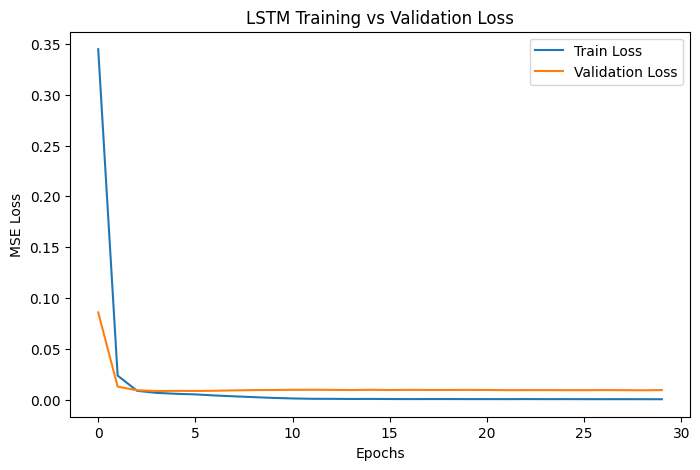

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('LSTM Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

# ***Cell 8 Evaluate on Test Set***

In [ ]:
model.load_state_dict(torch.load(checkpoint_path))
model.eval()
predictions, actuals = [], []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        preds = model(batch_X).cpu().numpy()
        predictions.extend(preds)
        actuals.extend(batch_y.numpy())

predictions = np.array(predictions)
actuals = np.array(actuals)

mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mape = np.mean(np.abs((actuals - predictions) / np.clip(np.abs(actuals), 1e-3, None))) * 100
r2 = r2_score(actuals, predictions)

metrics_df = pd.DataFrame([
    {'Metric': 'MAE', 'Value': mae},
    {'Metric': 'RMSE', 'Value': rmse},
    {'Metric': 'MAPE (%)', 'Value': mape},
    {'Metric': 'R2 Score', 'Value': r2}
])

display(metrics_df)

,Metric,Value
0,MAE,0.079676
1,RMSE,0.095060
2,MAPE (%),9.631607
3,R2 Score,-0.192874


# ***Cell 9 Predicted vs Actual SOH***

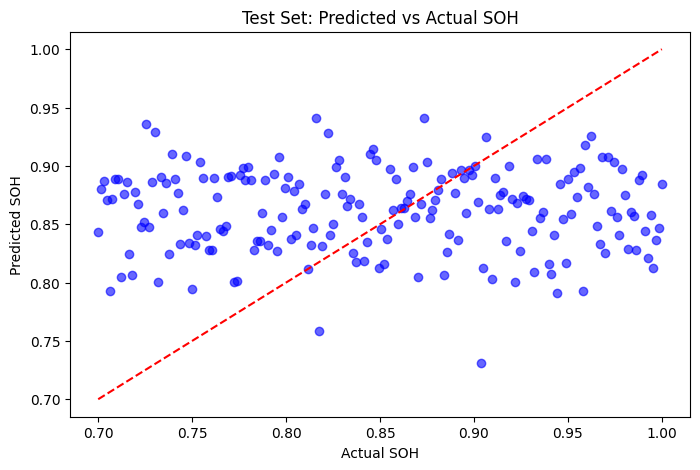

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(actuals, predictions, alpha=0.6, color='blue')
min_val = min(actuals.min(), predictions.min())
max_val = max(actuals.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.title('Test Set: Predicted vs Actual SOH')
plt.xlabel('Actual SOH')
plt.ylabel('Predicted SOH')
plt.show()